In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd

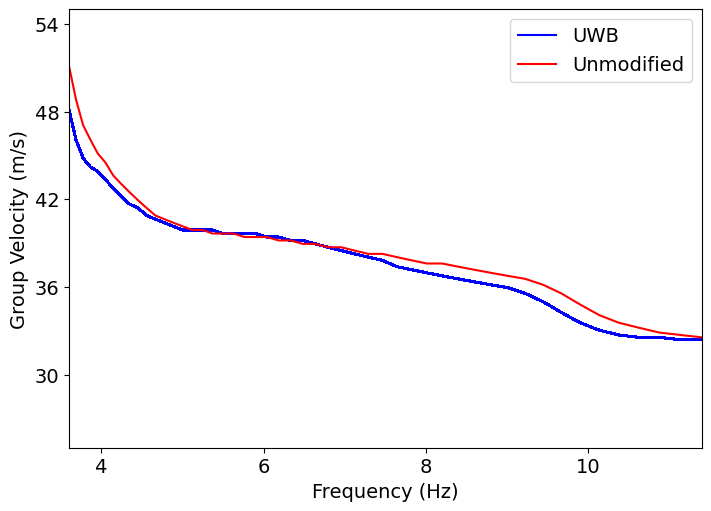

In [25]:
result_clock = np.load("output/neg_group_vel_1000_clock_uwb_50sInterval.npy")
result_normal = np.load("../PositionUncertainty/output/true_mean_lag_w8.npy")
freq = np.load("../PositionUncertainty/output/freqs.npy")

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(7,5), constrained_layout=True)
for i in range(1000):
    if i == 0:
        plt.plot(freq, result_clock[i], "blue", label = "UWB")
    plt.plot(freq, result_clock[i], "blue")

plt.plot(freq,56.9/result_normal, "red", label="Unmodified")
plt.legend()
# Increase the font size for the axis labels
plt.xlabel('Frequency (Hz)')
plt.ylabel('Group Velocity (m/s)')

# Get the current axes
ax = plt.gca()

# Limit the number of ticks on x and y axes
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Increase the tick label font size
#plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_ylim(25,55)
plt.xlim(3.6,11.4)
plt.show()

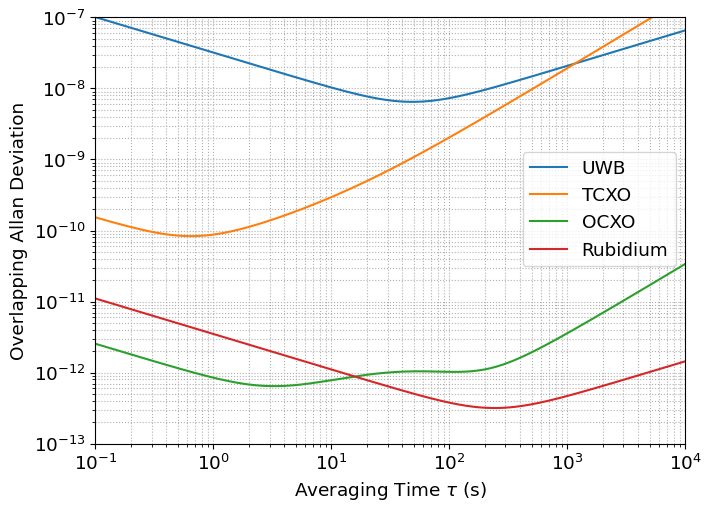

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def sigma_2Sd_sq(tau, sigma1_sq, sigma2_sq, d):
    """
    Returns the *variance* of the 2-state-with-constant-drift OADEV contribution.
    sigma1_sq = σ₁² in [s]
    sigma2_sq = σ₂² in [s⁻¹]
    d          = drift in [s⁻²]
    """
    return (sigma1_sq / tau) + (sigma2_sq * tau / 3.0) + (d**2 * (tau**2) / 2.0)

def sigma_Mj_sq(tau, U, R):
    """
    Returns the *variance* of a single Gauss–Markov OADEV contribution.
    U, R = parameters for that GM process
    """
    # Expression for GM variance from the paper:
    # σ_Mj²(τ) = U * [ -3 + 4 e^(-Rτ) - e^(-2Rτ) + 2 R τ ] / (R² τ²)
    return U * (
        -3.0
        + 4.0*np.exp(-R*tau)
        - np.exp(-2.0*R*tau)
        + 2.0*R*tau
    ) / ( (R**2) * (tau**2) )

def sigma_total(tau, sigma1_sq, sigma2_sq, d, U_list, R_list):
    """
    Returns the total OADEV (not variance) for the 2-state-with-drift + Markov processes.
    """
    # Start with the 2-state-drift variance
    val = sigma_2Sd_sq(tau, sigma1_sq, sigma2_sq, d)
    # Add each GM variance
    for (U, R) in zip(U_list, R_list):
        val += sigma_Mj_sq(tau, U, R)
    return np.sqrt(val)

# === Clock Parameters from Table ===
# Each entry: (σ₁², σ₂², d, [U list], [R list])
# All units must be consistent with the functions above:
#   - σ₁² in seconds
#   - σ₂² in 1/seconds
#   - d in 1/seconds²
#   - U, R for Gauss–Markov processes (dimensionless / 1/s)

clocks = {
    "UWB": {
        "sigma1_sq": 1.02e-15,  # σ₁²
        "sigma2_sq": 1.29e-18,  # σ₂²
        "d": 1.47e-22,          # drift
        "U": [],               # no Markov processes
        "R": [],
    },
    "TCXO": {
        "sigma1_sq": 2.3e-21,
        "sigma2_sq": 1.5e-20,
        "d": 2.7e-11,
        "U": [],
        "R": [],
    },
    "OCXO": {
        "sigma1_sq": 6.48e-25,
        "sigma2_sq": 4.04e-27,
        "d": 4.75e-15,
        "U": [2.57e-24],
        "R": [0.042]
    },
    "Rubidium": {
        "sigma1_sq": 1.22e-23,
        "sigma2_sq": 6.21e-28,
        "d": 0.0,
        "U": [],
        "R": [],
    },
    
    # "Hydrogen Maser": {
    #     "sigma1_sq": 6.13e-28,
    #     "sigma2_sq": 1.74e-35,
    #     "d": 0.0,
    #     "U": [],
    #     "R": [],
    # },
    # "Optical Ref. OSR1064": {
    #     "sigma1_sq": 5.46e-31,
    #     "sigma2_sq": 6.76e-31,
    #     "d": 0.0,
    #     "U": [1.80e-30, 8.46e-31],
    #     "R": [1.58, 0.26],
    # },
    # "Optical Iodine": {
    #     "sigma1_sq": 3.57e-29,
    #     "sigma2_sq": 3.64e-33,
    #     "d": 0.0,
    #     "U": [1.07e-29, 5.52e-30, 7.07e-30],
    #     "R": [0.157, 0.013, 1.57e-3],
    # },   
}

# === Generate OADEV curves ===
# Tau range: adjust as needed. Here 0.1 s to 1e5 s
tau_vals = np.logspace(-1, 4, 300)

plt.rcParams.update({'font.size': 13.3})

plt.figure(figsize=(7,5), constrained_layout=True)

for label, params in clocks.items():
    s1_sq = params["sigma1_sq"]
    s2_sq = params["sigma2_sq"]
    d     = params["d"]
    Ulist = params["U"]
    Rlist = params["R"]

    oadev = []
    for tau in tau_vals:
        val = sigma_total(tau, s1_sq, s2_sq, d, Ulist, Rlist)
        oadev.append(val)

    plt.loglog(tau_vals, oadev, label=label)

plt.xlabel(r"Averaging Time $\tau$ (s)")
plt.ylabel("Overlapping Allan Deviation")
# plt.title("OADEV for Different Clock Types (2-state + Drift + GM)")
plt.grid(True, which="both", ls=":")
plt.ylim(10e-14, 10e-8)
plt.xlim(10e-2, 10e3)
plt.legend(
    loc='center right',        # anchor the legend's center-left point...
    bbox_to_anchor=(1, 0.55)  # ...at 0% along x-axis and 55% up the y-axis
)
plt.show()